### step 1:import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

### step 2:load dataset

In [29]:
df=pd.read_csv("prediction.csv.csv",encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### step 3:clean dataset

In [7]:
df=df[['v1','v1']]
df.columns=['Label','Message']
df.head()

,Label,Message
0,ham,ham
1,ham,ham
2,spam,spam
3,ham,ham
4,ham,ham


### step 4:dataset information

In [8]:
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### step 5:missing values


In [9]:
print(df.isnull().sum())

Label      0
Message    0
dtype: int64


### step 6:spam vs ham distribution

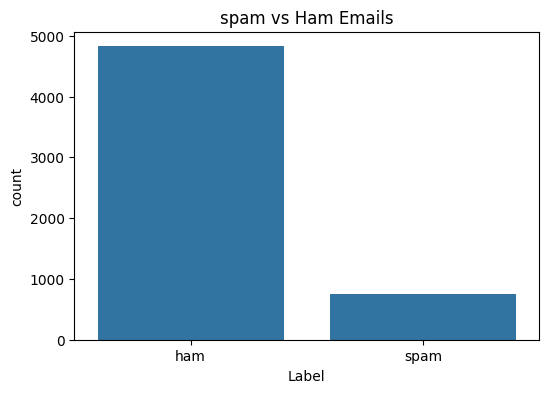

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Label',
    data=df
)

plt.title("spam vs Ham Emails")
plt.show()

### step 7:email length analysis

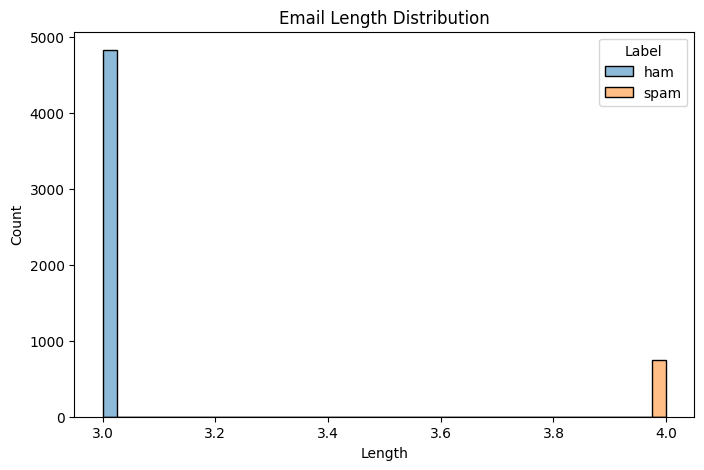

In [12]:
df['Length']=df['Message'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Length',
    hue='Label',
    bins=40
)

plt.title("Email Length Distribution")
plt.show()

### step 8:Encode labels

In [13]:
df['Label']=df['Label'].map({
    'ham':0,
    'spam':1
})

### step 9:features and target

In [14]:
x=df['Message']
y=df['Label']

### step 10:TF-IDF vectorization

In [15]:
vectorizer=TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

x=vectorizer.fit_transform(x)

### step 11:Train-Test split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

### step 12:naive bayes model

In [21]:
nb=MultinomialNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

print("Naive Bayes Accuracy:",accuracy_score(y_test,y_pred))

Naive Bayes Accuracy: 1.0


### step 13:Logistic regression model

In [22]:
lr=LogisticRegression(
    max_iter=1000
)

lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

print("Logistic Regression Accuracy:",
     accuracy_score(y_test,y_pred))

Logistic Regression Accuracy: 1.0


### step 14:model comparsion graph

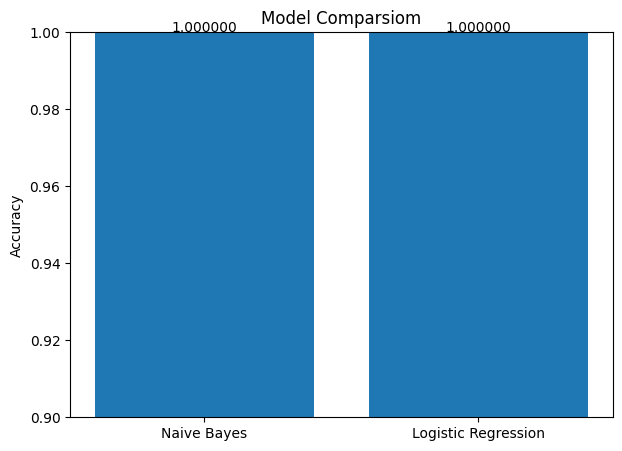

In [24]:
models=[
    "Naive Bayes",
    "Logistic Regression"
]

scores=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)
]

plt.figure(figsize=(7,5))

bars=plt.bar(models,scores)

for bar in bars:
    y=bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        f"{y:3f}",
        ha='center'
    )

plt.ylim(0.9,1.0)
plt.title("Model Comparsiom")
plt.ylabel("Accuracy")
plt.show()

### step 15:confusion matrix

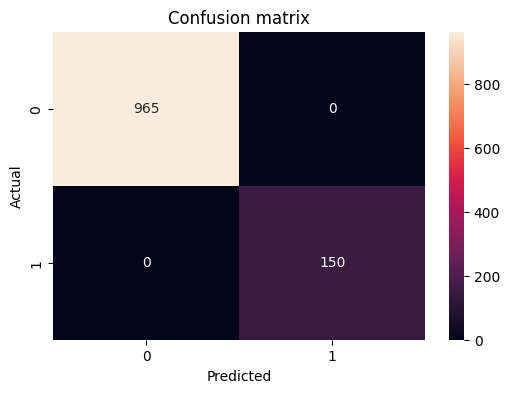

In [25]:
cm=confusion_matrix(
    y_test,y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### step 16:classification report

In [26]:
print(
    classification_report(y_test,y_pred)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       965
           1       1.00      1.00      1.00       150

    accuracy                           1.00      1115
   macro avg       1.00      1.00      1.00      1115
weighted avg       1.00      1.00      1.00      1115



### step 17:predict custom email

In [27]:
email=["Congrulations!you won a free iPhone.Click now."]
email_vector=vectorizer.transform(email)
prediction=nb.predict(email_vector)

if prediction[0]==1:
    print("spam email")
else:
    print("ham email")

ham email


### step 18:test multiple email

In [30]:
emails=[
    "You have won 10000 rupess claim now",
    "hi shubham ,your interview is scheduled tomorrow",
    "Free netflix subscription click here"
]

emails_vector=vectorizer.transform(emails)
predictions=nb.predict(emails_vector)

for email,pred in zip(emails,predictions):
    print("\nEmail:",email)

    if pred==1:
        print("prediction: spam")
    else:
        print("prediction: ham")

    


Email: You have won 10000 rupess claim now
prediction: ham

Email: hi shubham ,your interview is scheduled tomorrow
prediction: ham

Email: Free netflix subscription click here
prediction: ham
